**Imports**

In [1]:
import pandas as pd
import torch
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

c:\Users\charifmayssa\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 

**Data Preparation**

In [2]:
# Load labeled data
df = pd.read_csv(
    '../data/processed/labeled_reviews.csv'  # was a Kaggle-only path; now points at the repo's own processed data
)

# Drop rows where pseudo_label is missing (some rows had no rating_deviation, e.g. missing appVersion)
df = df.dropna(subset=['content_clean', 'pseudo_label'])
df['pseudo_label'] = df['pseudo_label'].astype(int)

df = df[['content_clean', 'pseudo_label']].rename(columns={'content_clean': 'text', 'pseudo_label': 'label'})

from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df.reset_index(drop=True))

print(f"Train: {len(train_ds)} | Test: {len(test_ds)} | Label balance:\n{df['label'].value_counts()}")

Train: 67203 | Test: 16801 | Label balance:
label
0    73218
1    10786
Name: count, dtype: int64


**Tokenization**

In [3]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def tokenize(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=128)

train_ds = train_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)
train_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/67203 [00:00<?, ? examples/s]

Map:   0%|          | 0/16801 [00:00<?, ? examples/s]

**Compute note:** fine-tuning DistilBERT on ~67k reviews for 2 epochs took about 17 minutes on a Kaggle GPU. On CPU-only hardware this can take multiple hours. If you don't have a GPU available locally, run this notebook on Kaggle/Colab instead and make sure to run the new save step below before the session ends -- that's the step that was missing before, which is why the last training run's weights were lost.

**Fine-tune**

In [4]:
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

args = TrainingArguments(
    output_dir='./distilbert_checkpoints'  # relative path that works both locally and on Kaggle,
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy='epoch',
    logging_steps=50,
    save_strategy='no'
)

trainer = Trainer(model=model, args=args, train_dataset=train_ds, eval_dataset=test_ds)
trainer.train()

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, 

Epoch,Training Loss,Validation Loss
1,0.628340,0.659966
2,0.590491,0.649132


TrainOutput(global_step=4202, training_loss=0.6383121918633347, metrics={'train_runtime': 1020.1418, 'train_samples_per_second': 131.752, 'train_steps_per_second': 4.119, 'total_flos': 4451103295939584.0, 'train_loss': 0.6383121918633347, 'epoch': 2.0})

**Evaluation Harness**

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

def evaluate_model(y_true, y_pred, y_proba=None, model_name='Model'):
    print(f"=== {model_name} ===")
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion matrix:\n", cm)
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc(fpr, tpr):.2f})")
        plt.plot([0,1],[0,1],'k--')
        plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
        plt.legend(); plt.title('ROC Curve')

**Running DistilBERT through the harness**

=== DistilBERT ===
              precision    recall  f1-score   support

           0       0.90      0.98      0.94     14644
           1       0.63      0.27      0.38      2157

    accuracy                           0.89     16801
   macro avg       0.77      0.62      0.66     16801
weighted avg       0.87      0.89      0.87     16801

Confusion matrix:
 [[14306   338]
 [ 1570   587]]


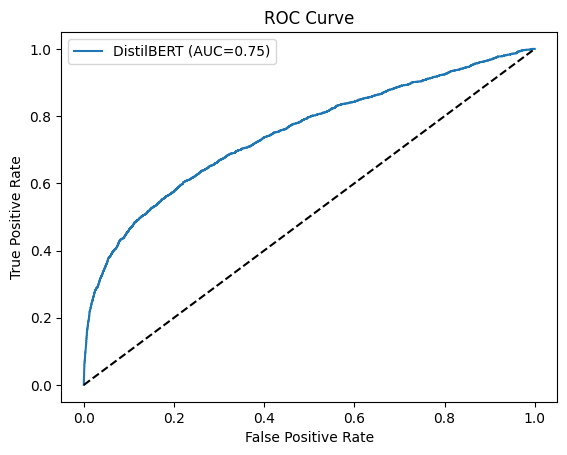

In [6]:
preds_output = trainer.predict(test_ds)
y_pred = preds_output.predictions.argmax(axis=1)
y_proba = torch.softmax(torch.tensor(preds_output.predictions), dim=1)[:, 1].numpy()

evaluate_model(test_df['label'], y_pred, y_proba, 'DistilBERT')
plt.show()

## Save the Fine-Tuned Model

This step was missing before -- without it, everything above only exists inside this session's memory. `save_pretrained` writes the model weights and tokenizer config to disk so they survive after the kernel closes.

In [ ]:
save_dir = '../models/distilbert_fake_review'
model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)
print(f'Saved fine-tuned DistilBERT + tokenizer to: {save_dir}')
print('Note: this folder is ~250MB. Add it to .gitignore rather than committing it directly;')
print('commit the training code and metrics instead, and note in the report how to reproduce it.')
